# Mpesa trasactions analysis

**Problem Statement**


## Importing libraries

In [1]:
import pandas as  pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Loading data

In [2]:
transactions_df = pd.read_csv(r'C:\Users\Administrator\M-PESA-Transaction-Anomaly-Scorer\data\transactions.csv')
transactions_df.head()

,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend
0,TXN0008812,2024-02-24 17:00:00,568.16,17,0,withdraw,5,24,USER01250,3208.326086,0.177089,1137600.0,0,0,1
1,TXN0001970,2024-07-10 07:00:00,1264.23,7,0,withdraw,2,10,USER00922,309.857126,4.080042,309600.0,0,0,0
2,TXN0009625,2024-11-18 11:00:00,735.39,11,0,buy_goods,0,18,USER00342,4456.268596,0.165024,3362400.0,0,0,0
3,TXN0003226,2024-09-09 11:00:00,8769.07,11,0,deposit,0,9,USER00935,2283.433868,3.840300,2239200.0,0,0,0
4,TXN0008942,2024-10-03 17:00:00,20811.30,17,0,withdraw,3,3,USER00888,4519.251559,4.605032,2700000.0,0,1,0


In [3]:
transactions_df.tail(10)

,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend
9990,TXN0006611,2024-11-01 16:00:00,146.670000,16,0,deposit,4,1,USER01658,3204.096831,0.045776,5508000.0,0,0,0
9991,TXN0007073,2024-03-28 08:00:00,489.578461,8,0,paybill,3,28,USER01104,4593.787755,0.106574,342000.0,0,0,0
9992,TXN0003467,2024-06-05 15:00:00,5833.460000,15,0,paybill,2,5,USER00870,802.209000,7.271746,9252000.0,0,0,0
9993,TXN0005540,2024-02-08 09:00:00,868.780000,9,0,withdraw,3,8,USER00099,1674.321179,0.518885,NaN,0,0,0
9994,TXN0005265,2024-08-07 13:00:00,2829.190000,13,0,send_money,2,7,USER01251,569.973885,4.963719,5961600.0,0,0,0
9995,TXN0006795,2024-01-10 11:00:00,5915.910000,11,0,withdraw,2,10,USER01136,3712.492545,1.593514,691200.0,0,0,0
9996,TXN0008931,2024-09-09 10:00:00,274.860000,10,0,buy_goods,0,9,USER01026,3030.333554,0.090703,6037200.0,0,0,0
9997,TXN0009424,2024-05-11 18:00:00,1685.630000,18,0,send_money,5,11,USER01067,4418.990756,0.381451,1155600.0,0,0,1
9998,TXN0006186,2024-02-22 16:00:00,2156.870000,16,0,send_money,3,22,USER00179,828.003301,2.604905,NaN,0,0,0
9999,TXN0001455,2024-11-01 18:00:00,4337.630000,18,0,paybill,4,1,USER01445,2735.067805,1.585931,2775600.0,0,0,0


In [4]:
transactions_df.sample(15)

,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend
335,TXN0006915,2024-04-04 10:00:00,2441.860000,10,0,buy_goods,3,4,USER00899,4982.948696,0.490043,4057200.0,0,0,0
1698,TXN0002266,2024-10-27 14:00:00,8064.920442,14,0,send_money,6,27,USER00309,940.471371,8.575402,6393600.0,0,0,1
2121,TXN0008224,2024-07-29 12:00:00,37805.640171,12,0,paybill,0,29,USER01168,1697.462085,22.271861,9676800.0,0,1,0
3096,TXN0004898,2024-10-20 09:00:00,1627.720000,9,0,withdraw,6,20,USER00848,1221.017737,1.333085,8380800.0,0,0,1
6202,TXN0005978,2024-05-17 13:00:00,1271.410000,13,0,deposit,4,17,USER00336,2483.359997,0.511972,4154400.0,0,0,0
2781,TXN0007876,2024-01-31 14:00:00,3303.248453,14,0,withdraw,2,31,USER00607,2075.950263,1.591198,1918800.0,0,0,0
1057,TXN0000656,2024-02-11 11:00:00,671.590000,11,0,withdraw,6,11,USER01104,4593.787755,0.146195,266400.0,0,0,1
7121,TXN0005287,2024-09-08 08:00:00,2387.100000,8,0,buy_goods,6,8,USER01225,2815.097217,0.847964,NaN,0,0,1
5482,TXN0001779,2024-10-29 17:00:00,2612.413169,17,0,paybill,1,29,USER00515,4537.741195,0.575708,15724800.0,0,0,0
1707,TXN0002711,2024-05-31 13:00:00,1791.742332,13,0,buy_goods,4,31,USER00618,1440.020569,1.244248,5698800.0,0,0,0


In [5]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10000 non-null  str    
 1   timestamp         10000 non-null  str    
 2   amount_kes        10000 non-null  float64
 3   hour_of_day       10000 non-null  int64  
 4   is_fraud          10000 non-null  int64  
 5   transaction_type  10000 non-null  str    
 6   day_of_week       10000 non-null  int64  
 7   day_of_month      10000 non-null  int64  
 8   user_id           10000 non-null  str    
 9   user_avg_amount   10000 non-null  float64
 10  amount_deviation  10000 non-null  float64
 11  time_diff         8085 non-null   float64
 12  is_night          10000 non-null  int64  
 13  is_large_tx       10000 non-null  int64  
 14  is_weekend        10000 non-null  int64  
dtypes: float64(4), int64(7), str(4)
memory usage: 1.6 MB


In [6]:
transactions_df.shape

(10000, 15)

## EDA

In [7]:
transactions_df.describe()

,amount_kes,hour_of_day,is_fraud,day_of_week,day_of_month,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,8.085000e+03,10000.000000,10000.000000,10000.000000
mean,5449.707221,12.891400,0.030000,2.971100,15.82660,2601.598245,5.865728,4.600130e+06,0.030000,0.076600,0.285400
std,9973.055808,3.671124,0.170596,2.013472,8.81446,1404.008208,30.716192,4.466349e+06,0.170596,0.265969,0.451627
min,16.330000,0.000000,0.000000,0.000000,1.00000,201.509369,0.004864,0.000000e+00,0.000000,0.000000,0.000000
25%,957.132445,10.000000,0.000000,1.000000,8.00000,1387.362808,0.389409,1.263600e+06,0.000000,0.000000,0.000000
50%,2217.586770,13.000000,0.000000,3.000000,16.00000,2612.677947,1.029228,3.272400e+06,0.000000,0.000000,0.000000
75%,5286.252500,15.000000,0.000000,5.000000,23.00000,3837.639021,2.900232,6.613200e+06,0.000000,0.000000,1.000000
max,70000.000000,23.000000,1.000000,6.000000,31.00000,4995.126057,1128.044820,3.057120e+07,1.000000,1.000000,1.000000


## Matplotlib

### Bar chart

In [8]:
ttypes_count= transactions_df['transaction_type'].value_counts()
ttypes_count

transaction_type
send_money    3294
buy_goods     2651
paybill       2087
withdraw      1286
deposit        682
Name: count, dtype: int64

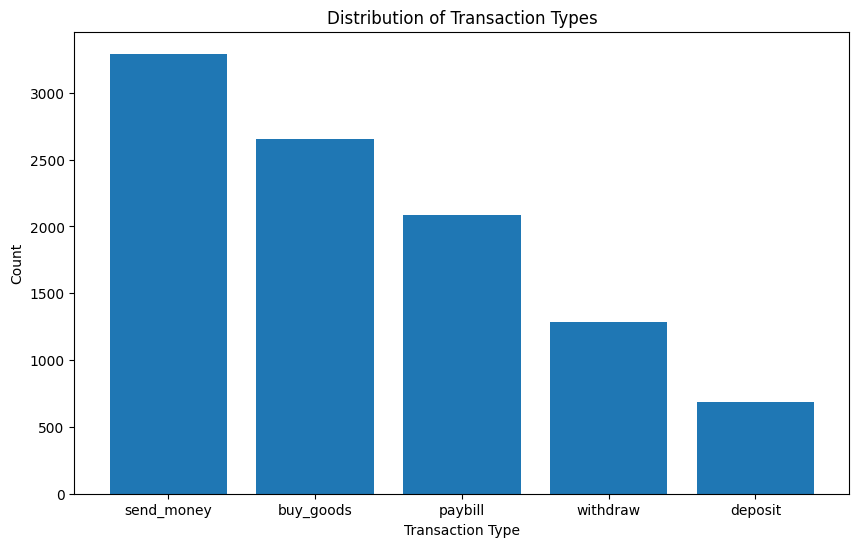

In [9]:
plt.figure(figsize=(10,6))
plt.bar(ttypes_count.index, ttypes_count.values)
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')
#plt.xticks(rotation=45)
plt.show()

### Distribution of Transaction Amounts (KES)

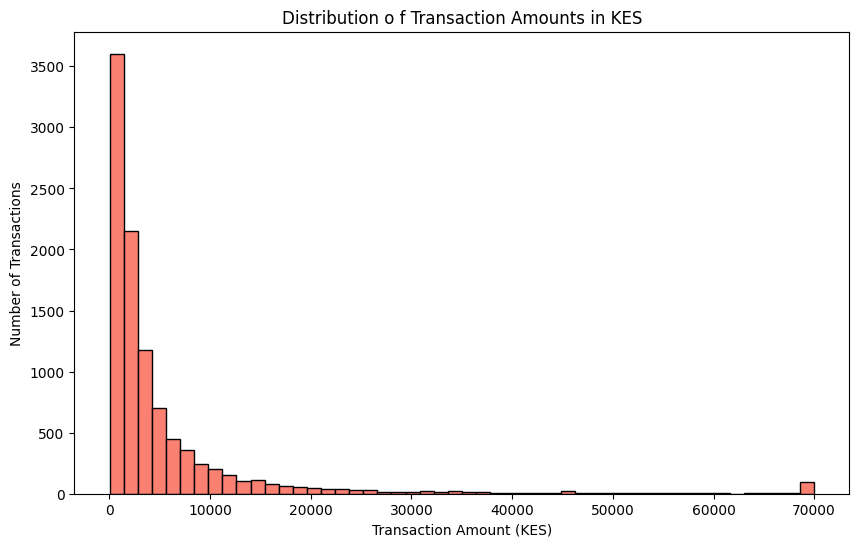

In [10]:
plt.figure(figsize=(10,6))
plt.hist(transactions_df['amount_kes'], bins=50, color='salmon', edgecolor='black')
plt.xlabel('Transaction Amount (KES)')
plt.ylabel('Number of Transactions')
plt.title('Distribution o f Transaction Amounts in KES')
plt.show()

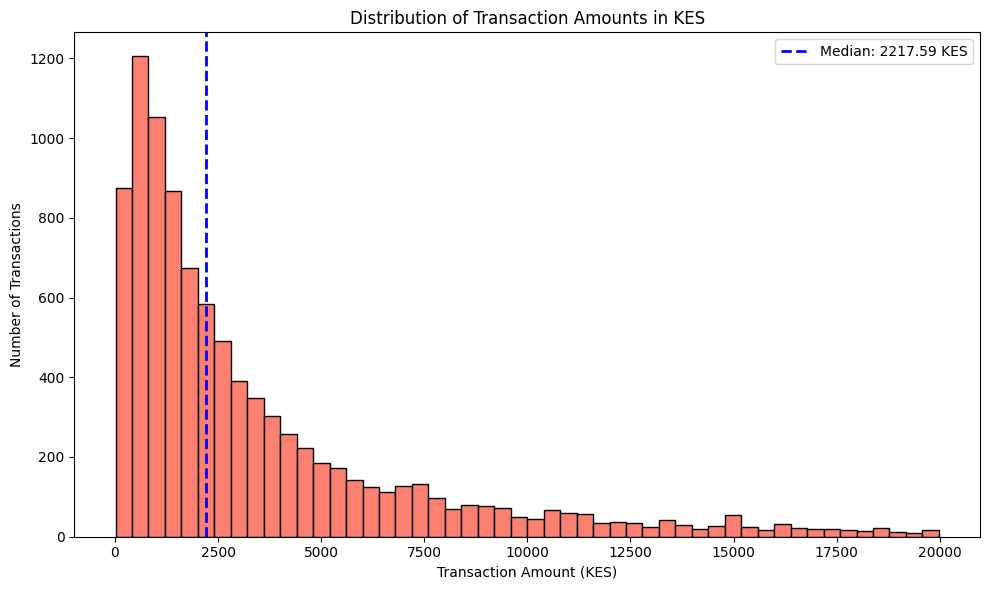

In [11]:
plt.figure(figsize=(10,6))
plt.hist(transactions_df[transactions_df['amount_kes']<20000]['amount_kes'], bins=50, color='salmon', edgecolor='black')
plt.xlabel('Transaction Amount (KES)')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Transaction Amounts in KES')
median_amount = transactions_df['amount_kes'].median()
plt.axvline(median_amount, color='blue', linestyle='dashed', linewidth=2, label=f'Median: {median_amount:.2f} KES')
plt.legend()
plt.tight_layout()
plt.show() 

### Pie charts

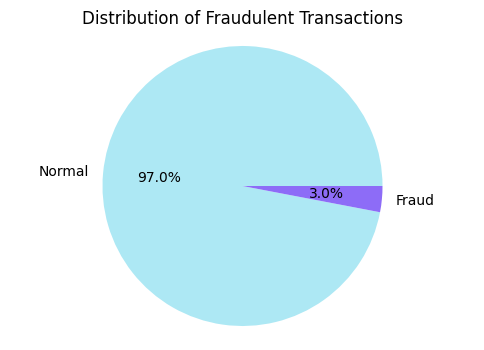

In [12]:
fraud_count = transactions_df['is_fraud'].value_counts()
labels = ['Normal', 'Fraud']
colours = ['#ADE8F4', "#8d6cf7"]
plt.figure(figsize=(6,4))
plt.pie(fraud_count, labels=labels,colors=colours, autopct='%1.1f%%')
plt.title('Distribution of Fraudulent Transactions')
plt.axis('equal')

plt.show()

### Scatter plot

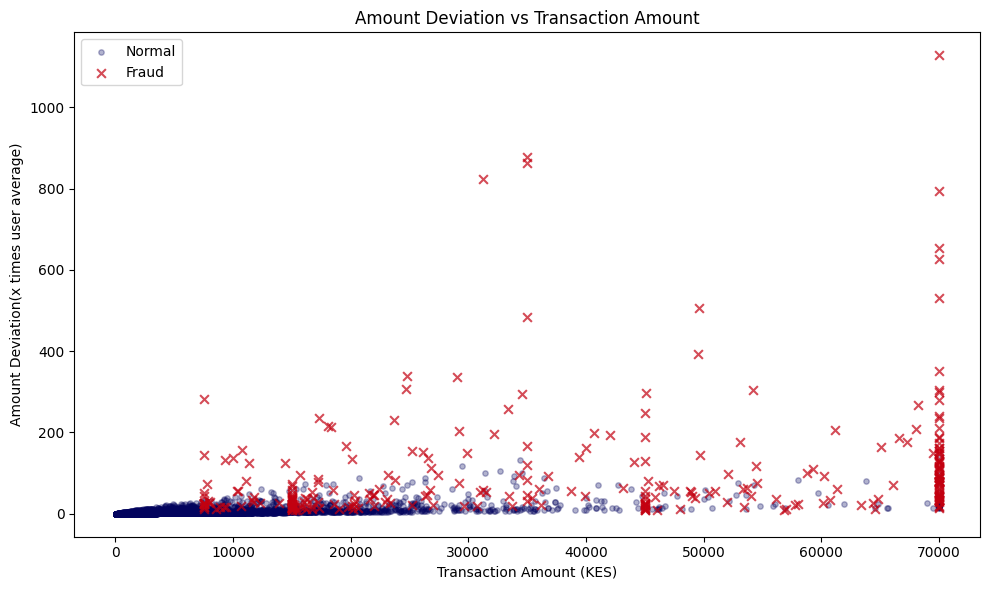

In [13]:
normal = transactions_df[transactions_df['is_fraud'] == 0]
fraud = transactions_df[transactions_df['is_fraud'] == 1]
plt.figure(figsize=(10,6))

plt.scatter(normal['amount_kes'], normal['amount_deviation'], color='#03045E', label='Normal', alpha=0.3,s=15)
plt.scatter(fraud['amount_kes'], fraud['amount_deviation'], color='#C30010', label='Fraud', alpha=0.7,s=40,marker='x')
plt.xlabel('Transaction Amount (KES)')
plt.ylabel('Amount Deviation(x times user average)')
plt.title('Amount Deviation vs Transaction Amount')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
normal['amount_deviation'].describe()

count    9700.000000
mean        2.914026
std         6.994750
min         0.004864
25%         0.376887
50%         0.977913
75%         2.614304
max       139.435983
Name: amount_deviation, dtype: float64

In [15]:
fraud['amount_deviation'].describe()

count     300.000000
mean      101.304099
std       143.327700
min         9.138971
25%        25.154741
50%        52.915712
75%       125.074250
max      1128.044820
Name: amount_deviation, dtype: float64

### Line chart

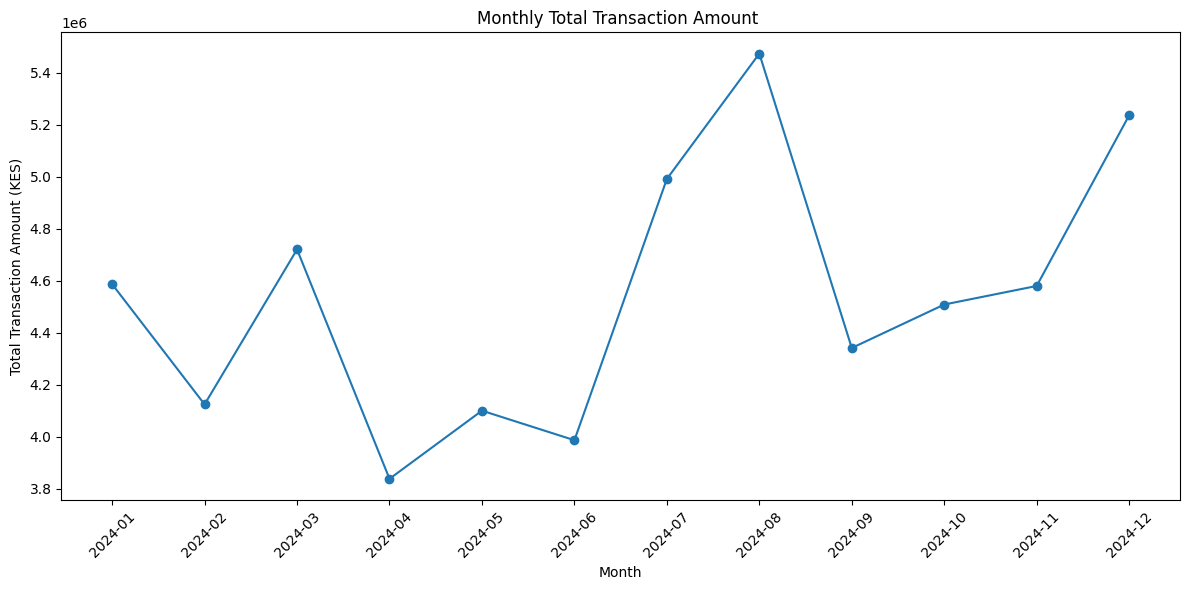

In [16]:
transactions_df['timestamp'] = pd.to_datetime(transactions_df['timestamp'])
transactions_df['month'] = transactions_df['timestamp'].dt.to_period('M')
monthly_volume = transactions_df.groupby('month')['amount_kes'].sum()
plt.figure(figsize=(12,6))
plt.plot(monthly_volume.index.astype(str), monthly_volume.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount (KES)')
plt.title('Monthly Total Transaction Amount ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

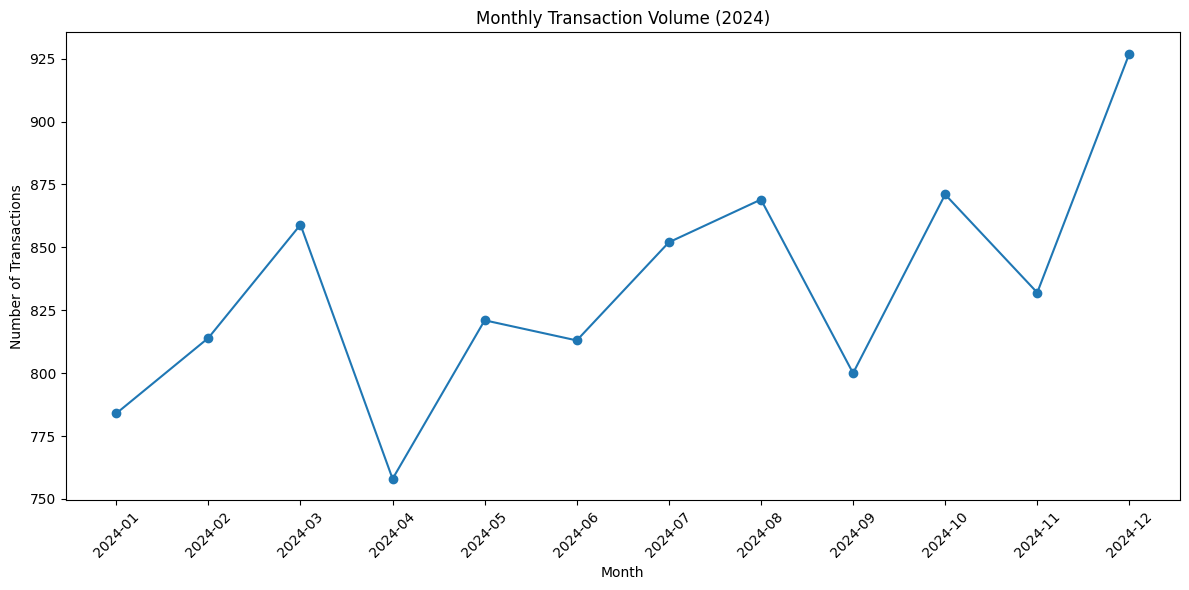

In [17]:
transactions_df['timestamp'] = pd.to_datetime(transactions_df['timestamp'])
transactions_df['month'] = transactions_df['timestamp'].dt.to_period('M')
monthly_volume = transactions_df.groupby('month').size()
plt.figure(figsize=(12,6))
plt.plot(monthly_volume.index.astype(str), monthly_volume.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.title('Monthly Transaction Volume (2024)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
monthly_volume


month
2024-01    784
2024-02    814
2024-03    859
2024-04    758
2024-05    821
2024-06    813
2024-07    852
2024-08    869
2024-09    800
2024-10    871
2024-11    832
2024-12    927
Freq: M, dtype: int64

In [19]:
transactions_df.head()

,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend,month
0,TXN0008812,2024-02-24 17:00:00,568.16,17,0,withdraw,5,24,USER01250,3208.326086,0.177089,1137600.0,0,0,1,2024-02
1,TXN0001970,2024-07-10 07:00:00,1264.23,7,0,withdraw,2,10,USER00922,309.857126,4.080042,309600.0,0,0,0,2024-07
2,TXN0009625,2024-11-18 11:00:00,735.39,11,0,buy_goods,0,18,USER00342,4456.268596,0.165024,3362400.0,0,0,0,2024-11
3,TXN0003226,2024-09-09 11:00:00,8769.07,11,0,deposit,0,9,USER00935,2283.433868,3.840300,2239200.0,0,0,0,2024-09
4,TXN0008942,2024-10-03 17:00:00,20811.30,17,0,withdraw,3,3,USER00888,4519.251559,4.605032,2700000.0,0,1,0,2024-10


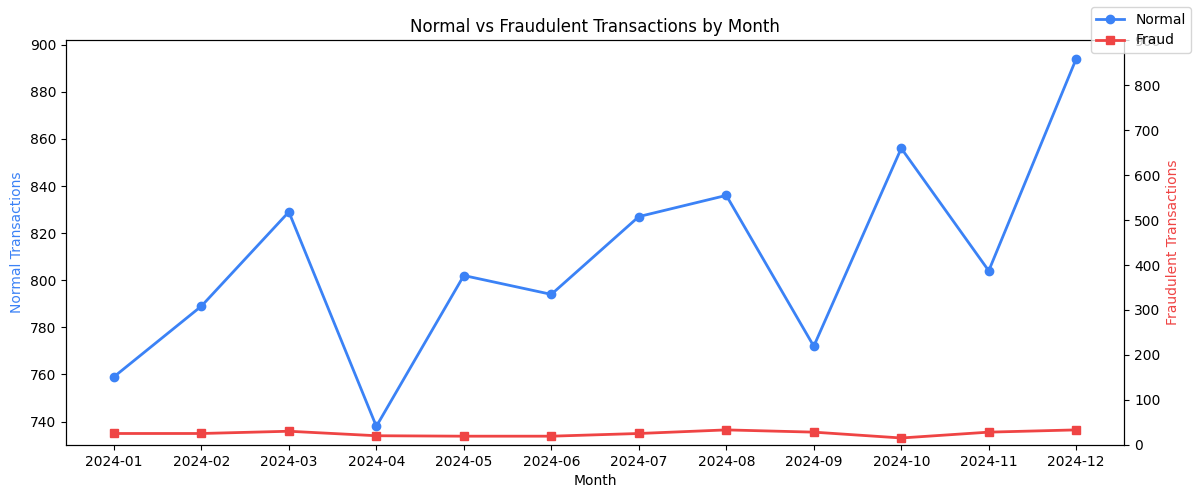

In [20]:
# Count monthly normal transactions
monthly_normal = transactions_df[transactions_df['is_fraud']==0].groupby('month').size()

# Count monthly fraud transactions
monthly_fraud  = transactions_df[transactions_df['is_fraud']==1].groupby('month').size()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Left y-axis: normal transaction counts (blue)
ax1.plot(monthly_normal.index.astype(str), monthly_normal.values,
        color='#3b82f6', linewidth=2, marker='o', label='Normal')
ax1.set_ylabel('Normal Transactions', color='#3b82f6')

# Right y-axis: fraud counts (red) — different scale
ax2 = ax1.twinx()  # twinx() creates a second y-axis sharing the same x-axis
ax2.plot(monthly_fraud.index.astype(str), monthly_fraud.values,
        color='#ef4444', linewidth=2, marker='s', label='Fraud')
ax2.set_ylabel('Fraudulent Transactions', color='#ef4444')
ax2.set_ylim(0,900)
plt.title('Normal vs Fraudulent Transactions by Month')
ax1.set_xlabel('Month')
plt.xticks(rotation=45)
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

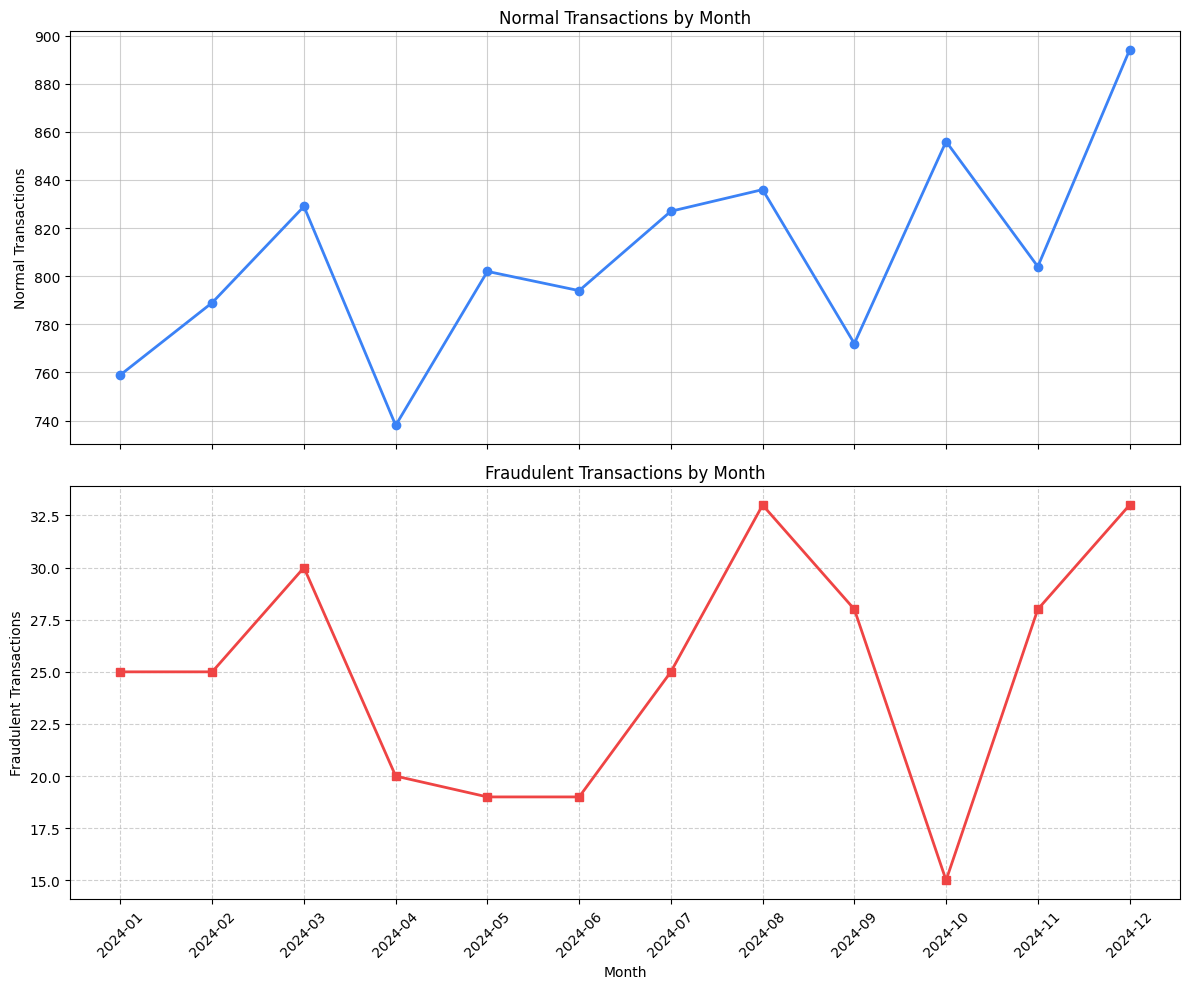

In [21]:
# Create a figure with 2 rows and 1 column
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# Top Plot: Normal Transactions
ax1.plot(monthly_normal.index.astype(str), monthly_normal.values,
        color='#3b82f6', linewidth=2, marker='o', label='Normal')
ax1.set_ylabel('Normal Transactions')
ax1.set_title('Normal Transactions by Month')
ax1.grid(True, linestyle='-', alpha=0.6)

# Bottom Plot: Fraudulent Transactions
ax2.plot(monthly_fraud.index.astype(str), monthly_fraud.values,
        color='#ef4444', linewidth=2, marker='s', label='Fraud')
ax2.set_ylabel('Fraudulent Transactions')
ax2.set_title('Fraudulent Transactions by Month')
ax2.set_xlabel('Month')
ax2.grid(True, linestyle='--', alpha=0.6)

# Formatting
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [22]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  str           
 1   timestamp         10000 non-null  datetime64[us]
 2   amount_kes        10000 non-null  float64       
 3   hour_of_day       10000 non-null  int64         
 4   is_fraud          10000 non-null  int64         
 5   transaction_type  10000 non-null  str           
 6   day_of_week       10000 non-null  int64         
 7   day_of_month      10000 non-null  int64         
 8   user_id           10000 non-null  str           
 9   user_avg_amount   10000 non-null  float64       
 10  amount_deviation  10000 non-null  float64       
 11  time_diff         8085 non-null   float64       
 12  is_night          10000 non-null  int64         
 13  is_large_tx       10000 non-null  int64         
 14  is_weekend        10000 non-null  

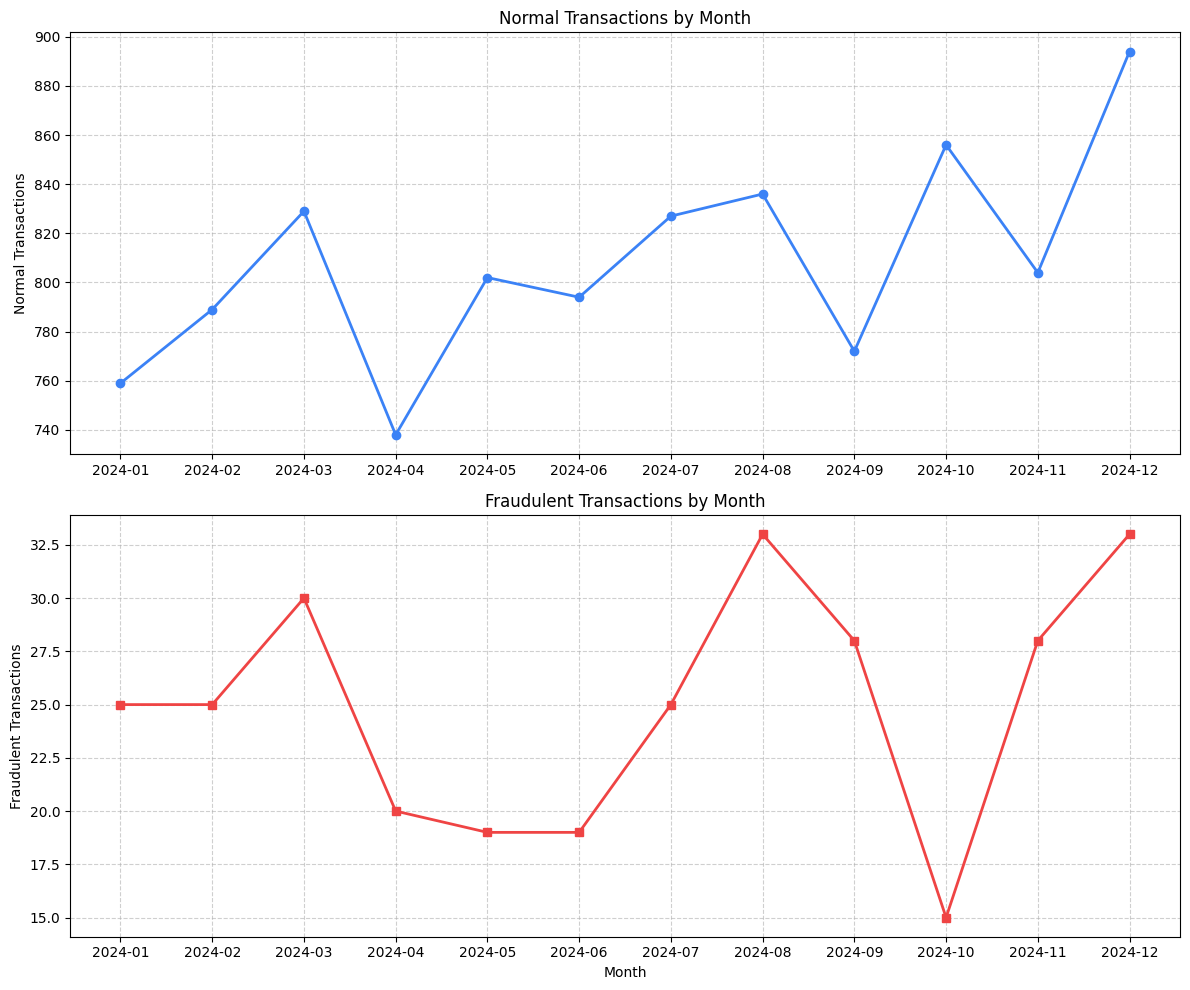

In [23]:
# Create a figure with 2 rows and 1 column
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Top Plot: Normal Transactions
ax1.plot(monthly_normal.index.astype(str), monthly_normal.values,
        color='#3b82f6', linewidth=2, marker='o', label='Normal')
ax1.set_ylabel('Normal Transactions')
ax1.set_title('Normal Transactions by Month')
ax1.grid(True, linestyle='--', alpha=0.6)

# Bottom Plot: Fraudulent Transactions
ax2.plot(monthly_fraud.index.astype(str), monthly_fraud.values,
        color='#ef4444', linewidth=2, marker='s', label='Fraud')
ax2.set_ylabel('Fraudulent Transactions')
ax2.set_title('Fraudulent Transactions by Month')
ax2.set_xlabel('Month')
ax2.grid(True, linestyle='--', alpha=0.6)

# Formatting
plt.tight_layout()
plt.show()


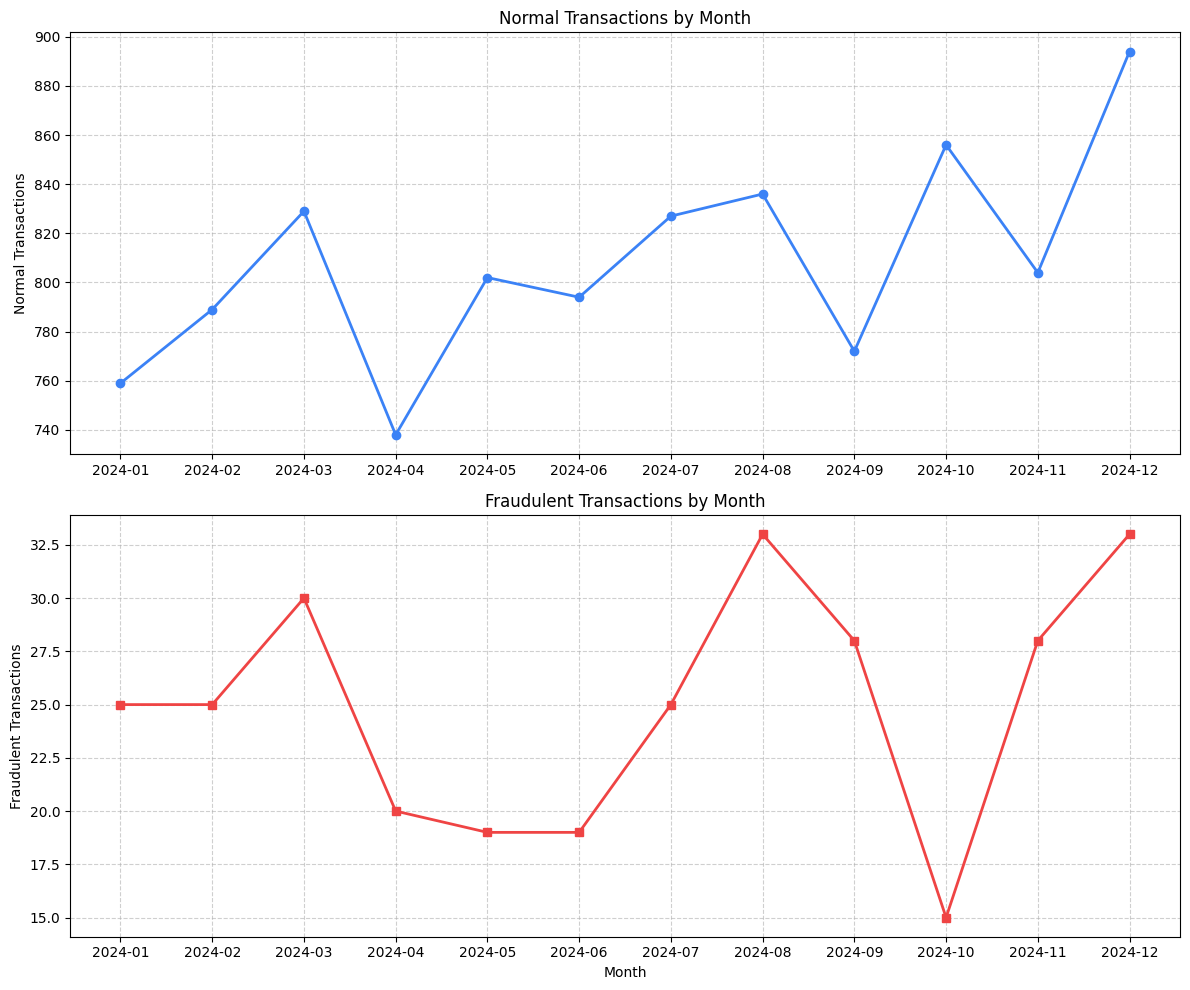

In [24]:
# Create a figure with 2 rows and 1 column
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Top Plot: Normal Transactions
ax[0].plot(monthly_normal.index.astype(str), monthly_normal.values,
        color='#3b82f6', linewidth=2, marker='o', label='Normal')
ax[0].set_ylabel('Normal Transactions')
ax[0].set_title('Normal Transactions by Month')
ax[0].grid(True, linestyle='--', alpha=0.6)

# Bottom Plot: Fraudulent Transactions
ax[1].plot(monthly_fraud.index.astype(str), monthly_fraud.values,
        color='#ef4444', linewidth=2, marker='s', label='Fraud')
ax[1].set_ylabel('Fraudulent Transactions')
ax[1].set_title('Fraudulent Transactions by Month')
ax[1].set_xlabel('Month')
ax[1].grid(True, linestyle='--', alpha=0.6)

# Formatting
plt.tight_layout()
plt.show()


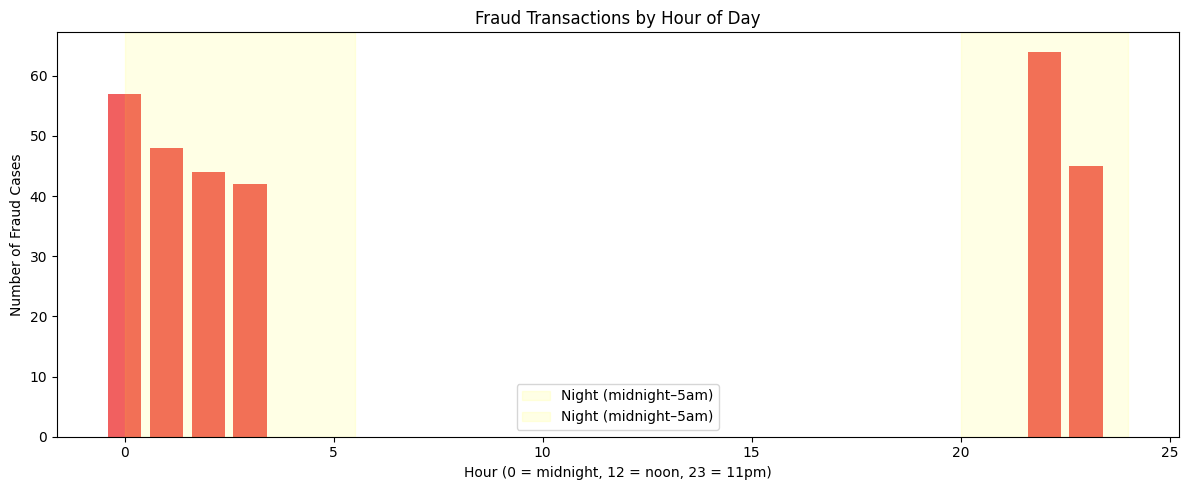

In [25]:
# Group by hour, count fraud cases in each hour
fraud_by_hour = transactions_df[transactions_df['is_fraud']==1].groupby('hour_of_day').size()

plt.figure(figsize=(12, 5))

plt.bar(fraud_by_hour.index, fraud_by_hour.values, color='#ef4444', alpha=0.85)

# Highlight the night hours (0-5am) with a shaded region
plt.axvspan(0, 5.5, alpha=0.1, color='yellow', label='Night (midnight–5am)')
plt.axvspan(20, 24, alpha=0.1, color='yellow', label='Night (midnight–5am)')
plt.title('Fraud Transactions by Hour of Day')
plt.xlabel('Hour (0 = midnight, 12 = noon, 23 = 11pm)')
plt.ylabel('Number of Fraud Cases')

plt.legend()
plt.tight_layout()
plt.show()

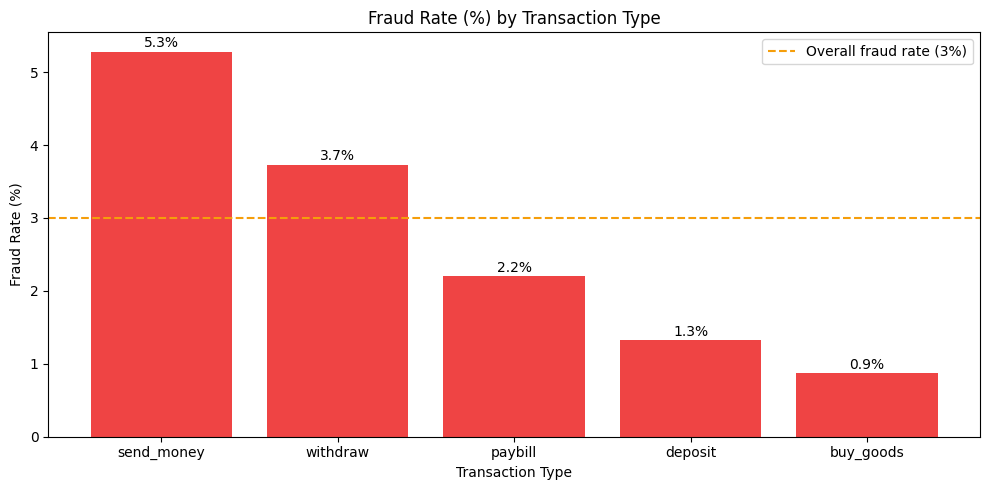

In [26]:
# Calculate the fraud rate for each transaction type
# We want: for each type, what % of transactions are fraud?
fraud_rate = transactions_df.groupby('transaction_type')['is_fraud'].mean() * 100
fraud_rate = fraud_rate.sort_values(ascending=False)

plt.figure(figsize=(10, 5))

bars = plt.bar(fraud_rate.index, fraud_rate.values, color='#ef4444')

# Add a dotted line showing the overall average fraud rate
plt.axhline(y=transactions_df['is_fraud'].mean() * 100,
           color='#f59e0b', linestyle='--', label='Overall fraud rate (3%)')
ax = plt.gca() # Get current axes
ax.bar_label(bars, fmt='%.1f%%', padding=1)
plt.title('Fraud Rate (%) by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

## Seaborn

In [27]:
# Create a readable label column for fraud status
# Instead of 0 and 1, we'll use "Normal" and "Fraud" for chart labels
transactions_df['fraud_label'] = transactions_df['is_fraud'].map({0: 'Normal', 1: 'Fraud'})

# Quick check -- see the first 3 rows
transactions_df.head(3)


,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend,month,fraud_label
0,TXN0008812,2024-02-24 17:00:00,568.16,17,0,withdraw,5,24,USER01250,3208.326086,0.177089,1137600.0,0,0,1,2024-02,Normal
1,TXN0001970,2024-07-10 07:00:00,1264.23,7,0,withdraw,2,10,USER00922,309.857126,4.080042,309600.0,0,0,0,2024-07,Normal
2,TXN0009625,2024-11-18 11:00:00,735.39,11,0,buy_goods,0,18,USER00342,4456.268596,0.165024,3362400.0,0,0,0,2024-11,Normal


### Countplot

<function matplotlib.pyplot.show(close=None, block=None)>

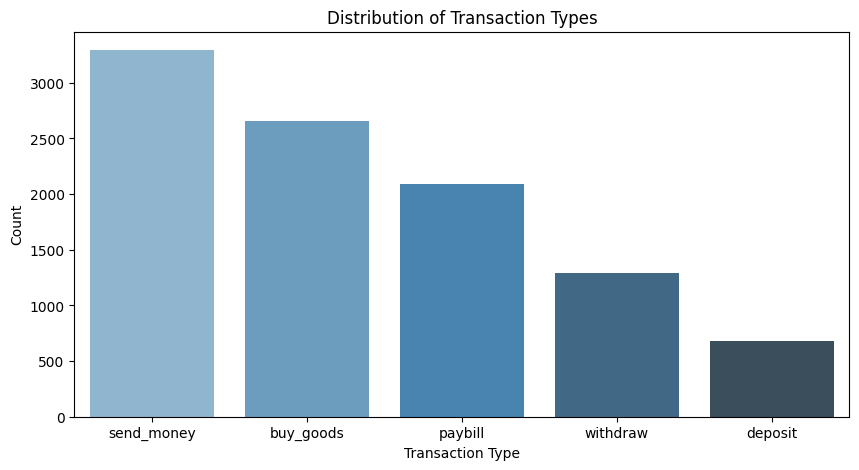

In [28]:
plt.figure(figsize=(10, 5))
sns.countplot(data=transactions_df,x='transaction_type',order=transactions_df['transaction_type'].value_counts().index,palette='Blues_d')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

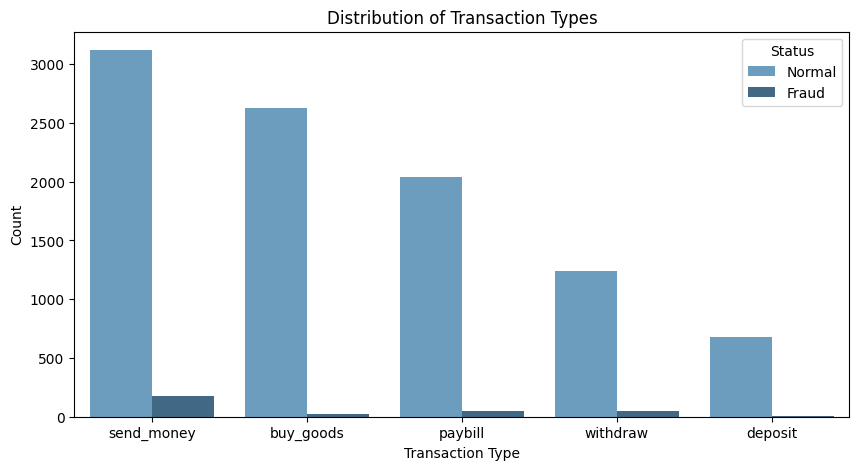

In [29]:
plt.figure(figsize=(10, 5))
sns.countplot(data=transactions_df,x='transaction_type',hue ='is_fraud' ,order=transactions_df['transaction_type'].value_counts().index,palette='Blues_d')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')
# Manually setting the legend labels
plt.legend(title='Status', labels=['Normal', 'Fraud'])
plt.show

### Boxplot

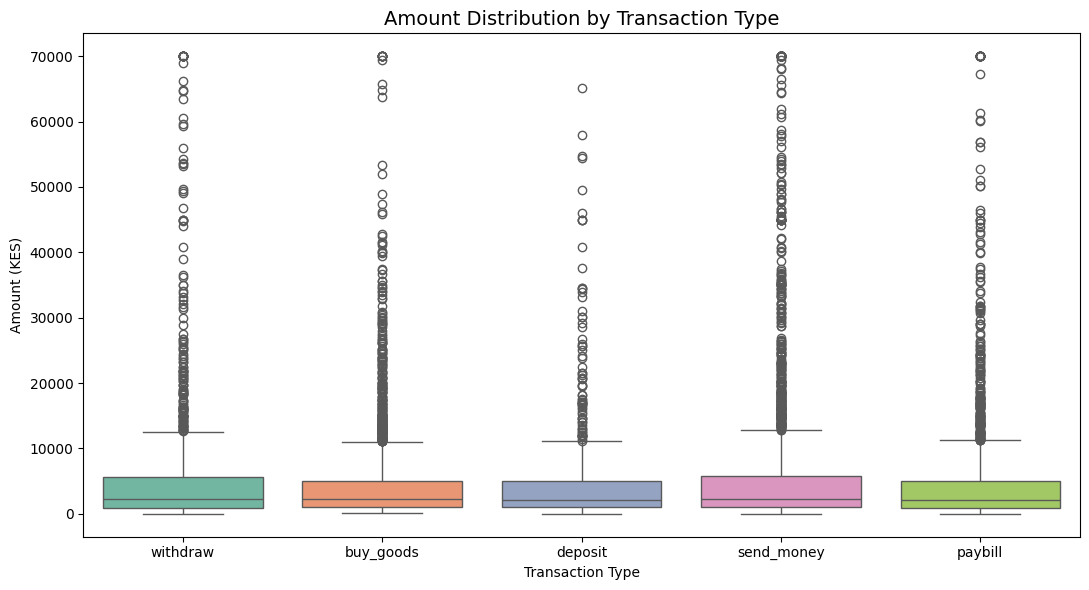

In [30]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=transactions_df,
    x='transaction_type',
    y='amount_kes',
    palette='Set2'   # 'Set2' is a Seaborn palette with distinct muted colours
)

plt.title('Amount Distribution by Transaction Type', fontsize=14)
plt.xlabel('Transaction Type')
plt.ylabel('Amount (KES)')
plt.tight_layout()
plt.show()

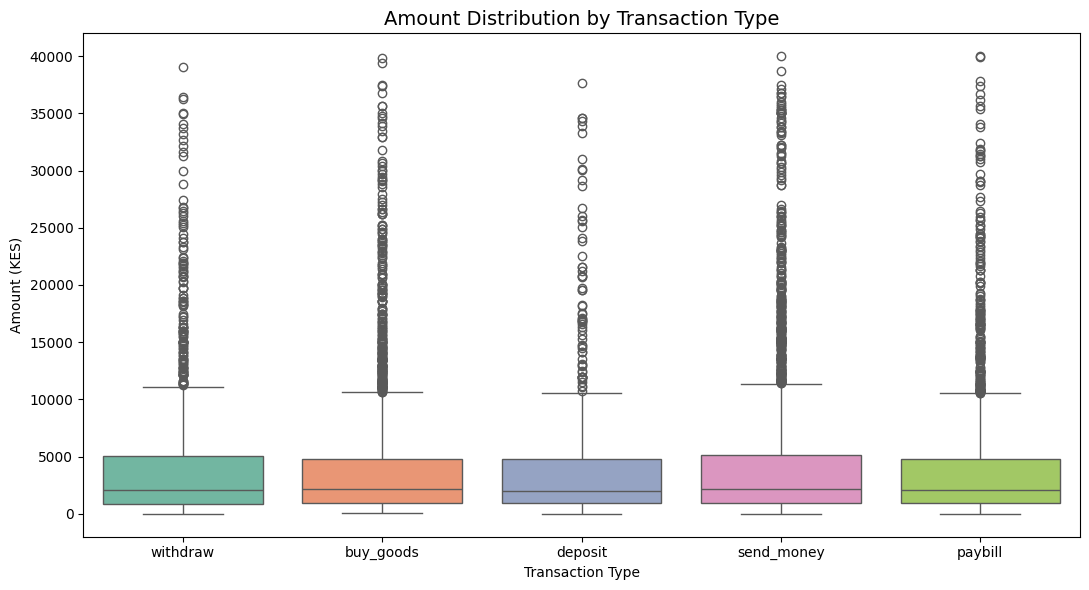

In [31]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=transactions_df[transactions_df['amount_kes']<40000],  # Filter out extreme outliers for better visualization
    x='transaction_type',
    y='amount_kes',
    palette='Set2'   # 'Set2' is a Seaborn palette with distinct muted colours
)

plt.title('Amount Distribution by Transaction Type', fontsize=14)
plt.xlabel('Transaction Type')
plt.ylabel('Amount (KES)')
plt.tight_layout()
plt.show()

In [32]:
transactions_df['fraud_label'] = transactions_df['is_fraud'].map({0: 'Normal', 1: 'Fraud'})
transactions_df.head()

,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend,month,fraud_label
0,TXN0008812,2024-02-24 17:00:00,568.16,17,0,withdraw,5,24,USER01250,3208.326086,0.177089,1137600.0,0,0,1,2024-02,Normal
1,TXN0001970,2024-07-10 07:00:00,1264.23,7,0,withdraw,2,10,USER00922,309.857126,4.080042,309600.0,0,0,0,2024-07,Normal
2,TXN0009625,2024-11-18 11:00:00,735.39,11,0,buy_goods,0,18,USER00342,4456.268596,0.165024,3362400.0,0,0,0,2024-11,Normal
3,TXN0003226,2024-09-09 11:00:00,8769.07,11,0,deposit,0,9,USER00935,2283.433868,3.840300,2239200.0,0,0,0,2024-09,Normal
4,TXN0008942,2024-10-03 17:00:00,20811.30,17,0,withdraw,3,3,USER00888,4519.251559,4.605032,2700000.0,0,1,0,2024-10,Normal


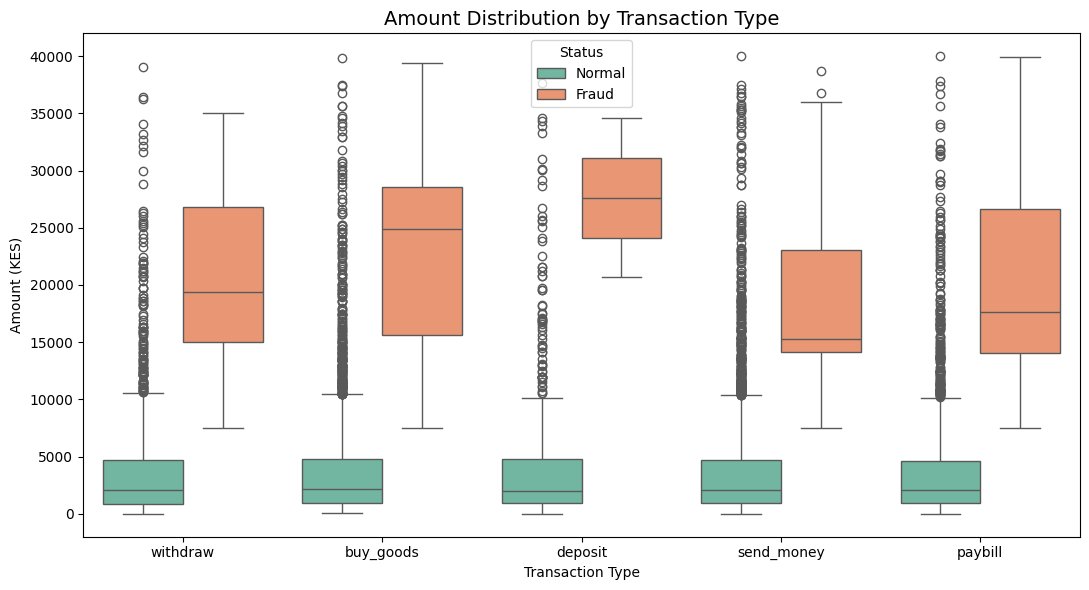

In [33]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=transactions_df[transactions_df['amount_kes']<40000],  # Filter out extreme outliers for better visualization
    x='transaction_type',
    y='amount_kes',
    hue='fraud_label',  # Add hue to differentiate between normal and fraud transactions   
    palette='Set2'   # 'Set2' is a Seaborn palette with distinct muted colours
)

plt.title('Amount Distribution by Transaction Type', fontsize=14)
plt.xlabel('Transaction Type')
plt.ylabel('Amount (KES)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

### Violinplot

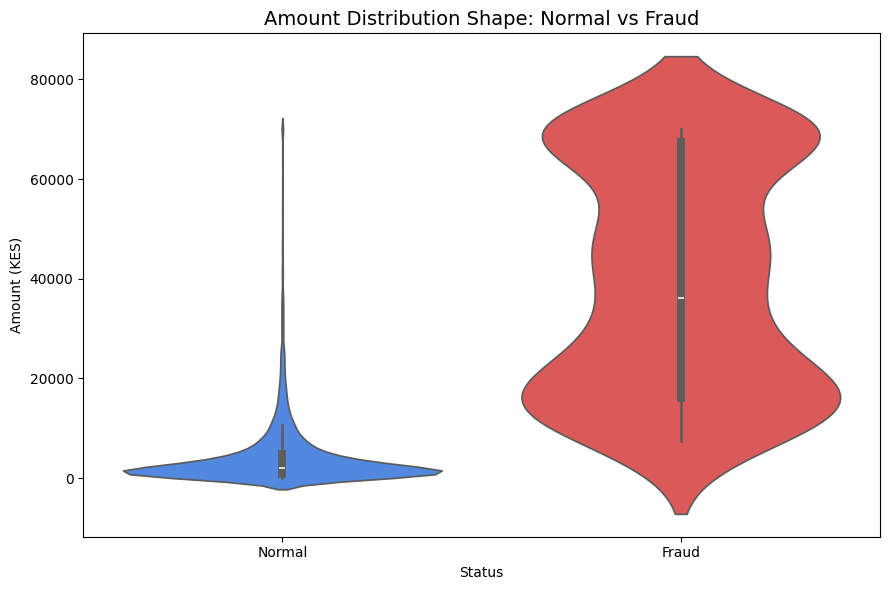

In [34]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=transactions_df,
    x='fraud_label',
    y='amount_kes',
    palette={'Normal': '#3b82f6', 'Fraud': '#ef4444'},
    inner='box'     # 'box' = draw a mini boxplot inside the violin
)

plt.title('Amount Distribution Shape: Normal vs Fraud', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Amount (KES)')
plt.tight_layout()
plt.show()

### Histplot

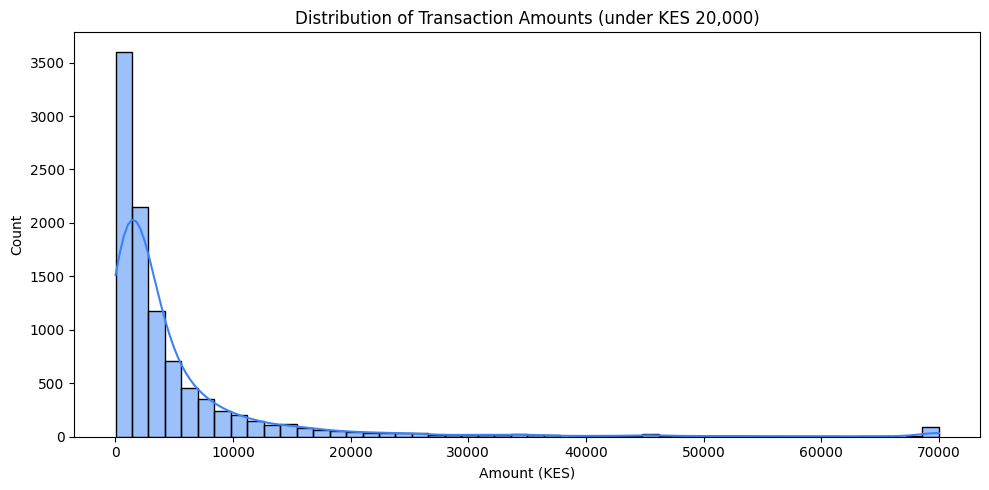

In [35]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=transactions_df,
    x='amount_kes',
    bins=50,
    kde=True,         # overlay the smooth KDE curve on top of the bars
    color='#3b82f6'
)

plt.title('Distribution of Transaction Amounts (under KES 20,000)')
plt.xlabel('Amount (KES)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Scatterplot

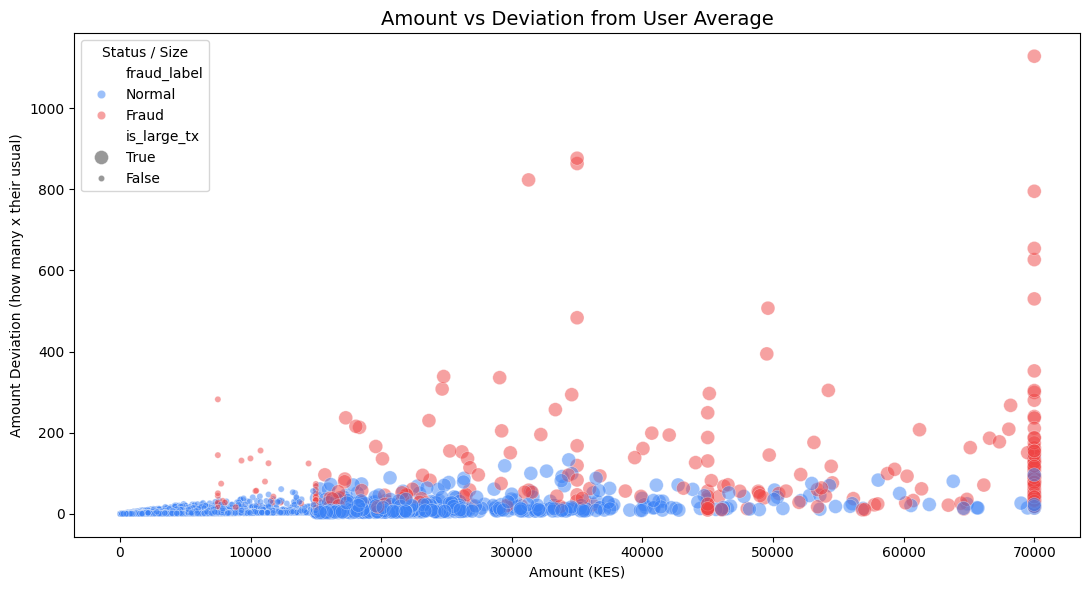

In [42]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=transactions_df,
    x='amount_kes',
    y='amount_deviation',
    hue='fraud_label',
    palette={'Normal': '#3b82f6', 'Fraud': '#ef4444'},
    alpha=0.5,      # semi-transparent so overlapping dots are visible
    size='is_large_tx',  # make large transactions show as bigger dots
    size_order=[True,False],  # ensure False (normal) is smaller than True (large)
    sizes=(20, 100)      # small dots for normal tx, bigger dots for large tx
   
)

plt.title('Amount vs Deviation from User Average', fontsize=14)
plt.xlabel('Amount (KES)')
plt.ylabel('Amount Deviation (how many x their usual)')
plt.legend(title='Status / Size')
plt.tight_layout()
plt.show()


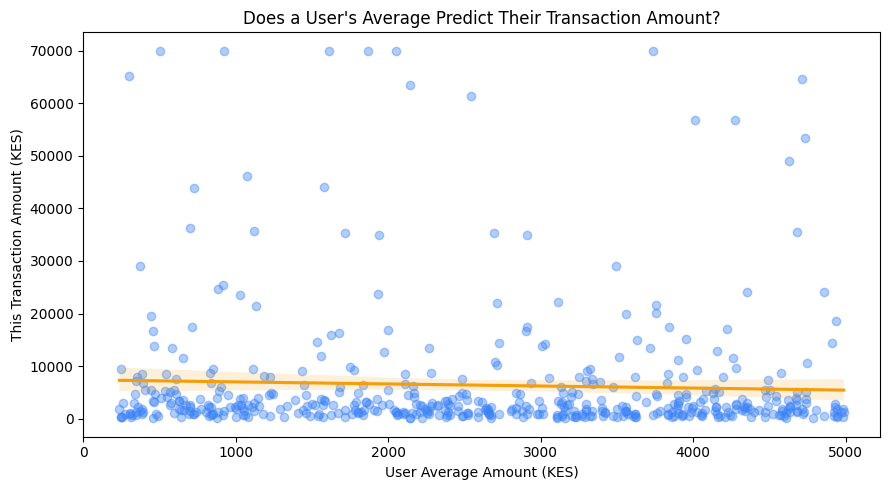

In [43]:
plt.figure(figsize=(9, 5))

# Sample 500 rows -- regplot can be slow on 10,000 points
sample = transactions_df.sample(500, random_state=42)

sns.regplot(
    data=sample,
    x='user_avg_amount',
    y='amount_kes',
    color='#3b82f6',
    scatter_kws={'alpha': 0.4},    # scatter_kws lets you pass args to the dots
    line_kws={'color': '#f59e0b'}  # line_kws controls the trend line style
)

plt.title("Does a User's Average Predict Their Transaction Amount?")
plt.xlabel('User Average Amount (KES)')
plt.ylabel('This Transaction Amount (KES)')
plt.tight_layout()
plt.show()

In [44]:
transactions_df.corr(numeric_only=True)

,amount_kes,hour_of_day,is_fraud,day_of_week,day_of_month,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend
amount_kes,1.000000,-0.105848,0.601629,0.001167,0.085543,-0.000065,0.503184,-0.126924,0.601629,0.806150,0.002813
hour_of_day,-0.105848,1.000000,-0.185626,0.007179,0.003461,0.008874,-0.108106,0.034179,-0.185626,-0.086736,0.004581
is_fraud,0.601629,-0.185626,1.000000,-0.008540,0.005256,-0.005845,0.546452,-0.202196,1.000000,0.467327,-0.020276
day_of_week,0.001167,0.007179,-0.008540,1.000000,0.003358,-0.013449,-0.013864,0.006285,-0.008540,0.000586,0.795435
day_of_month,0.085543,0.003461,0.005256,0.003358,1.000000,-0.011975,0.030105,0.012043,0.005256,0.073879,0.017231
user_avg_amount,-0.000065,0.008874,-0.005845,-0.013449,-0.011975,1.000000,-0.154392,0.011719,-0.005845,-0.006046,-0.004548
amount_deviation,0.503184,-0.108106,0.546452,-0.013864,0.030105,-0.154392,1.000000,-0.111414,0.546452,0.400535,-0.015035
time_diff,-0.126924,0.034179,-0.202196,0.006285,0.012043,0.011719,-0.111414,1.000000,-0.202196,-0.099755,0.008838
is_night,0.601629,-0.185626,1.000000,-0.008540,0.005256,-0.005845,0.546452,-0.202196,1.000000,0.467327,-0.020276
is_large_tx,0.806150,-0.086736,0.467327,0.000586,0.073879,-0.006046,0.400535,-0.099755,0.467327,1.000000,0.000319


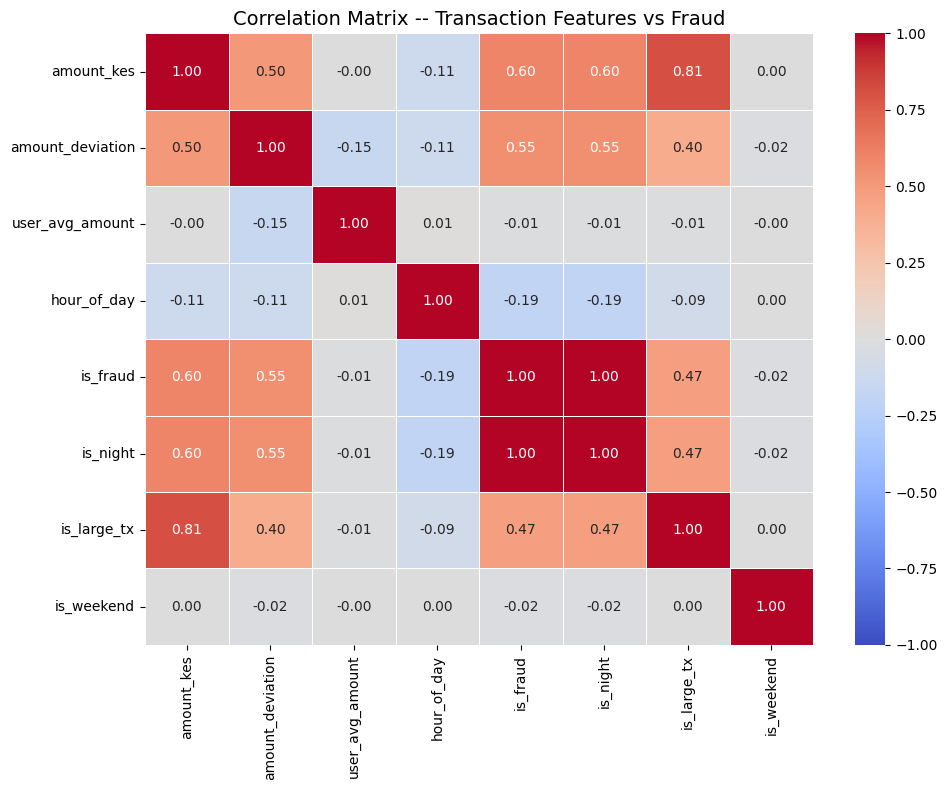

In [45]:
# Select only the numerical columns we care about for fraud analysis
cols = ['amount_kes', 'amount_deviation', 'user_avg_amount',
        'hour_of_day', 'is_fraud', 'is_night', 'is_large_tx', 'is_weekend']

# .corr() calculates pairwise correlations -- values range from -1 to +1
# +1 = perfectly positively correlated, 0 = no relationship, -1 = inversely correlated
corr_matrix = transactions_df[cols].corr().round(2)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,         # annot=True = show the actual number in each cell
    fmt='.2f',           # format: 2 decimal places
    cmap='coolwarm',    # blue=negative, white=zero, red=positive
    vmin=-1, vmax=1,    # fix the colour scale so 0 is always white
    linewidths=0.5       # thin lines between cells
)

plt.title('Correlation Matrix -- Transaction Features vs Fraud', fontsize=14)
plt.tight_layout()
plt.show()

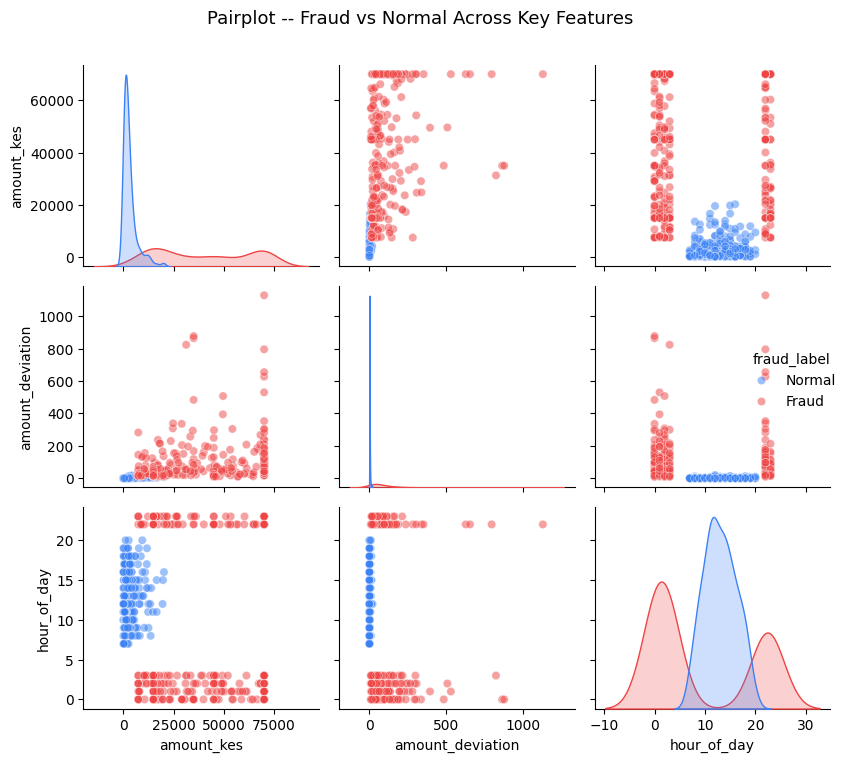

In [46]:
# Pairplot works best on a small sample -- it generates many charts
# We'll use 600 rows (300 normal + 300 fraud) for a balanced view
normal_sample = transactions_df[transactions_df['is_fraud']==0].sample(300, random_state=1)
fraud_all     = transactions_df[transactions_df['is_fraud']==1]  # all 300 fraud cases
df_pair = pd.concat([normal_sample, fraud_all])

# Only plot the most interesting numerical columns
pair_cols = ['amount_kes', 'amount_deviation', 'hour_of_day', 'fraud_label']

sns.pairplot(
    df_pair[pair_cols],
    hue='fraud_label',              # colour every chart by fraud status
    palette={'Normal': '#3b82f6', 'Fraud': '#ef4444'},
    diag_kind='kde',                  # diagonal: use KDE instead of histogram
    plot_kws={'alpha': 0.5}           # semi-transparent dots for scatter plots
)

plt.suptitle('Pairplot -- Fraud vs Normal Across Key Features', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [54]:
sns.set_theme(style='dark')

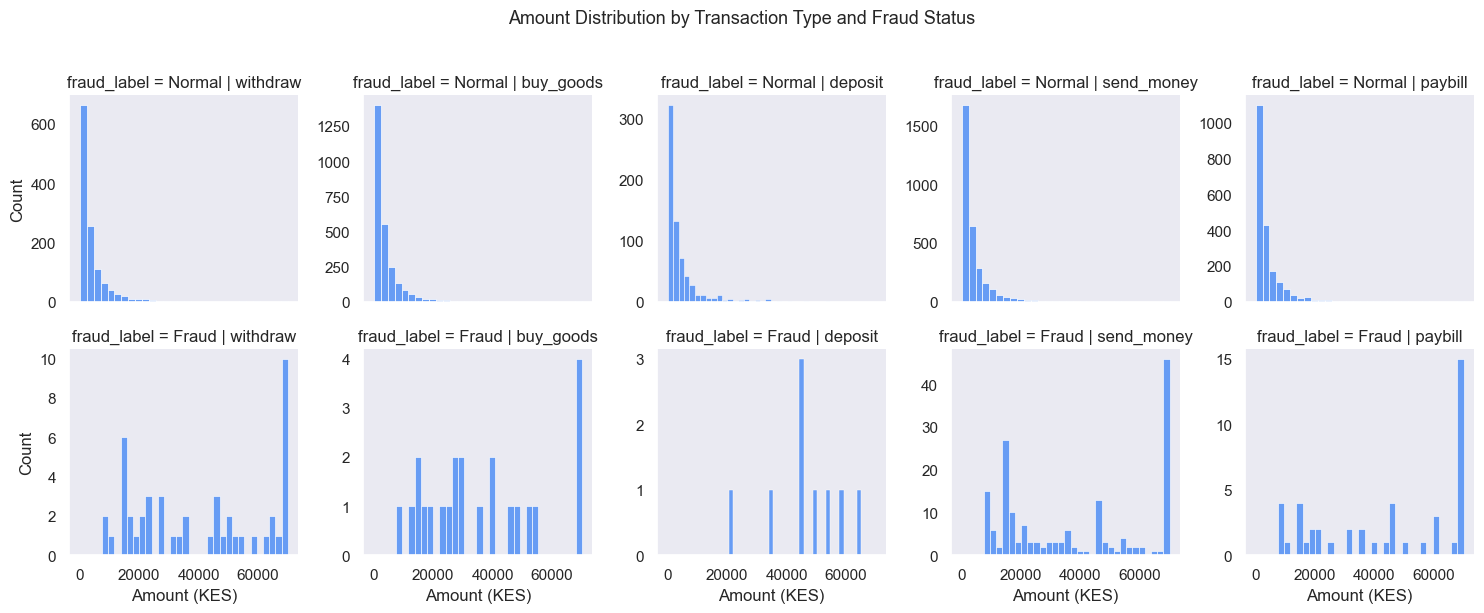

In [55]:
# Create a FacetGrid -- one column for each transaction type
# col_wrap=3 means: start a new row after 3 columns
g = sns.FacetGrid(
    transactions_df,
    col='transaction_type',
    row='fraud_label',  # add a row facet to split normal vs fraud 
    sharey=False         # let each chart have its own y-axis scale
)

# .map() applies a seaborn/matplotlib function to every cell
# The first argument is the function, the rest are the column names to use
g.map(sns.histplot, 'amount_kes', bins=30, color='#3b82f6')

g.set_titles(col_template='{col_name}')  # cleaner titles above each chart
g.set_axis_labels('Amount (KES)', 'Count')

plt.suptitle('Amount Distribution by Transaction Type and Fraud Status', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()